# CCE Moorings and MITgcm - Kinetic energy Analysis   

**Purpose**: Code for comparing the CCE mooring kinetic energy analysis. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import glob
from matplotlib.ticker import LogLocator
import matplotlib.patches as patches

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from plotScaleAnalysis import add_corner_label, add_freq_marker

Set plotting parameters

In [3]:
# Set processing parameters
option_filter = 'baroclinic'    # Options: 'total', 'baroclinic', 'barotropic'

# Set plotting parameters
cce1_sensor_depth = np.array([9, 19, 29, 39, 60, 75, 150])
cce2_sensor_depth = np.array([6, 14, 25, 44, 74])
cmap = cmocean.cm.deep_r
depth_lim = [0,200]        # Depth limits for spectrograms

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 20

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load CCE intermediate data and mitgcm time scale analysis data

In [4]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm = "/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/mooring_locations/"
if option_filter == 'baroclinic':
    file_mitgcm_KE_path = PATH + ROOT_mitgcm + "mitgcm_cce_mooring_ke_baroclinic.npz"
else: 
    file_mitgcm_KE_path = PATH + ROOT_mitgcm + "mitgcm_cce_mooring_ke.npz"

# Load data 
ds_mitgcm  = np.load(file_mitgcm_KE_path, allow_pickle=True)

# Extract data variables
depth_m          = np.abs(ds_mitgcm['depth'])
lon_m            = ds_mitgcm["lon"]
lat_m            = ds_mitgcm["lat"]
f_cpd_m          = ds_mitgcm["f_cpd"]

S_ke_m           = ds_mitgcm["S_ke"]
CI_m             = ds_mitgcm["CI_ke"]
FKE_m            = ds_mitgcm["FKE"]

#-------------------------------------------------------#
# CCE Data
#-------------------------------------------------------#
ROOT_cce = "/data/CCE/"
if option_filter == 'baroclinic':
    file_cce_KE_path = PATH + ROOT_cce + "cce_mooring_ke_baroclinic.npz"
else: 
    file_cce_KE_path = PATH + ROOT_cce + "cce_mooring_ke.npz"

# Load data 
ds_cce  = np.load(file_cce_KE_path, allow_pickle=True)

# Extract data variables
depth          = np.abs(ds_cce['depth'])
f_cpd          = ds_cce["f_cpd"]

S_ke           = ds_cce["S_ke"]
CI             = ds_cce["CI_ke"]
FKE            = ds_cce["FKE"]

# Mask fill values 
FKE_m = np.ma.masked_where(FKE_m == 0, FKE_m)
S_ke_m = np.ma.masked_where(S_ke_m == 0, S_ke_m)
CI_m = np.ma.masked_where(CI_m == 0, CI_m)

Set the tidal and inertial frequencies

In [5]:
# Compute the rotation rate of earth
omega = (7.2921*10**(-5))/(2*np.pi)              # Units: Hz 

# Compute the interial frequency at each mooring in units of cpd
f1_i = 2*omega*np.sin(np.deg2rad(lat_m[0])) * (86400)  # Units: cpd
f2_i = 2*omega*np.sin(np.deg2rad(lat_m[1])) * (86400)
f3_i = 2*omega*np.sin(np.deg2rad(lat_m[2])) * (86400)

# Compute the tidal frequencies (M2, K1) in cpd
T_m2 = 12.42 * (1/24)           # Units: days
T_k1 = 23.93 * (1/24)           # Units: days
f_m2 = 1 / T_m2
f_k1 = 1 / T_k1

Plot the kinetice energy depth spectrograms 

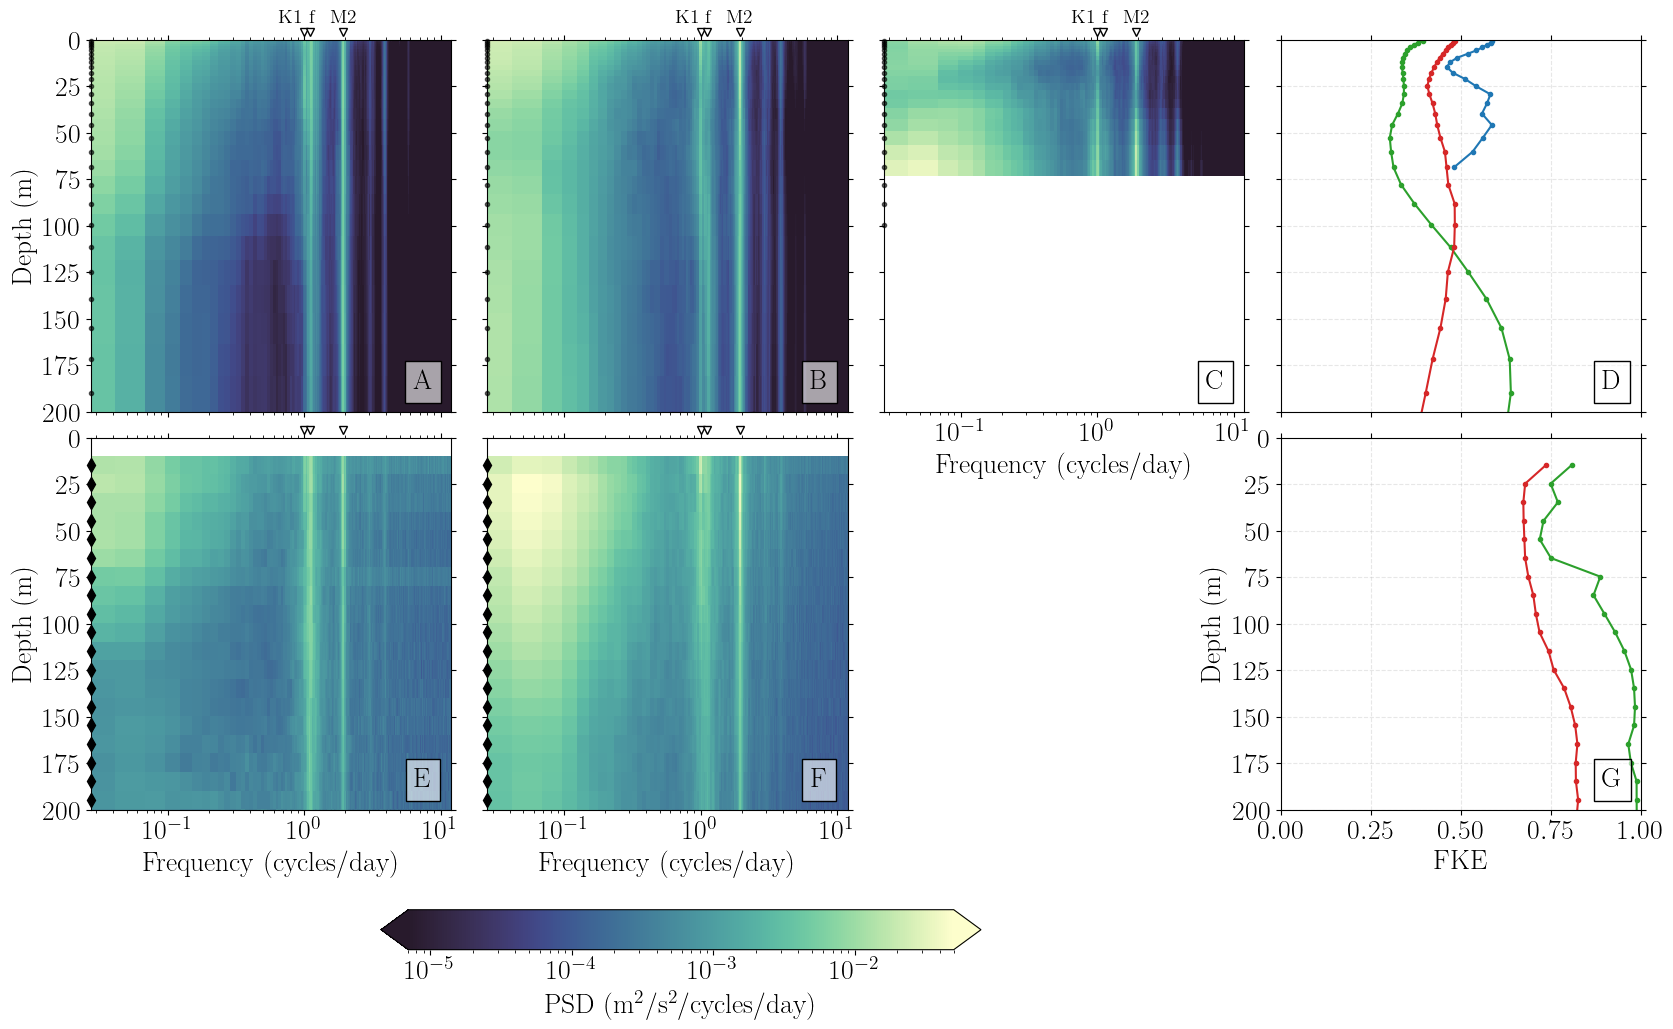

In [7]:
# Set depth levels for CCE3
depth_cce1_m = depth_m[depth_m <= 200]
depth_cce2_m = depth_m[depth_m <= 200]
depth_cce3_m = depth_m[depth_m <= 100]

depth_cce1 = depth[depth <= 200]
depth_cce2 = depth[depth <= 200]

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-6, vmax=5e-2) #mcolors.LogNorm(vmin=7e-6, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_m)
F, D = np.meshgrid(f_cpd, depth)

# Create figure
fig, axes = plt.subplots(2,4,figsize=(20, 10))
ax_flat = axes.flatten()

#--- Subplot 1 ---#  
ax = ax_flat[0]

# Plot CCE1 kinetic energy spectrogram
pc = ax.pcolormesh(F_m,D_m,S_ke_m[0,:,:],cmap=cmap,shading='auto',norm=norm)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_cce1_m, x_right),
    depth_cce1_m,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
ax.set_xticklabels([])

#--- Subplot 2 ---#  
ax = ax_flat[1]

# Plot CCE2 kinetic energy spectrogram
pc = ax.pcolormesh(F_m,D_m,S_ke_m[1,:,:],cmap=cmap,shading='auto',norm=norm)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_cce2_m, x_right),
    depth_cce2_m,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_yticklabels([])
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
ax.set_xticklabels([])

#--- Subplot 3 ---#  
ax = ax_flat[2]

# Plot CCE3 kinetic energy spectrogram
pc = ax.pcolormesh(F_m,D_m,S_ke_m[2,:,:],cmap=cmap,shading='auto',norm=norm)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 0.041 

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_cce3_m, x_right),
    depth_cce3_m,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax.set_xlabel('Frequency (cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_yticklabels([])
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)

#--- Subplot 4 ---# 
ax = ax_flat[3]

# Plot the profile of fraction of variance explained by high-frequencies for each mooring
ax.plot(FKE_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
ax.plot(FKE_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
ax.plot(FKE_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

# Set axis attributes
ax.set_yticklabels([])
ax.set_xlim(0,1)
ax.set_ylim(0,200)
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.set_xticklabels([])

#--- Subplot 5 ---# 
ax = ax_flat[4]

# Plot observed CCE1 kinetic energy spectrogram 
pc = ax.pcolormesh(F,D,S_ke[0,:,:],cmap=cmap,shading='auto', norm=norm)

# Plot the sensor depths 
ax.plot(
    np.zeros_like(depth_cce1),   # x = 0 → left edge in axis coords
    depth_cce1,
    marker='d', linestyle='None',
    color='k', markersize=7, alpha=1,
    transform=ax.get_yaxis_transform(),  # KEY LINE
    clip_on=False,
)

# Set figure attributes
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Frequency (cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)

#--- Subplot 6 ---#  
ax = ax_flat[5]

# Plot observed CCE2 kinetic energy spectrogram 
pc = ax.pcolormesh(F,D,S_ke[1,:,:],cmap=cmap,shading='auto', norm=norm)

# Set figure attributes
ax.set_xlabel('Frequency (cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
ax.set_yticklabels([])

# Plot the sensor depths 
ax.plot(
    np.zeros_like(depth_cce2),   # x = 0 → left edge in axis coords
    depth_cce2,
    marker='d', linestyle='None',
    color='k', markersize=7, alpha=1,
    transform=ax.get_yaxis_transform(),  # KEY LINE
    clip_on=False,
)

#--- Subplot 7 ---# 
ax = ax_flat[6]

# Turn off axis
ax.axis('off')

#--- Subplot 8 ---# 
ax = ax_flat[7]

# Plot the profile of fraction of variance explained by high-frequencies for each mooring
ax.plot(FKE[0,:],abs(depth),'.-',color='tab:green',label='CCE 1')
ax.plot(FKE[1,:],abs(depth),'.-',color='tab:red',label='CCE 2')

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlabel(f'FKE')
ax.set_xlim(0,1)
ax.set_ylim(0,200)
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.27, -0.03, 0.3, 0.04]) 
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (m$^2$/s$^2$/cycles/day)')

# Label each subplot
pos = [0.92, 0.08] 
add_corner_label(ax_flat[0], pos, 'A', fontsize = fontsize)
add_corner_label(ax_flat[1], pos, 'B', fontsize = fontsize)
add_corner_label(ax_flat[2], pos, 'C', fontsize = fontsize)
add_corner_label(ax_flat[3], pos, 'D', fontsize = fontsize)
add_corner_label(ax_flat[4], pos, 'E', fontsize = fontsize)
add_corner_label(ax_flat[5], pos, 'F', fontsize = fontsize)
add_corner_label(ax_flat[7], pos, 'G', fontsize = fontsize)

# Plot the tidal and inertial frequencies
for i in [0,1,2,4,5]:
    
    if (i == 0) | (i == 1) | (i == 2): 

        # K1 label shifted slightly left
        add_freq_marker(ax_flat[i], f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

        # f label shifted slightly right
        add_freq_marker(ax_flat[i], f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

        # M2 centered
        add_freq_marker(ax_flat[i], f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

    else: 

        # K1 label shifted slightly left
        add_freq_marker(ax_flat[i], f_k1, '', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

        # f label shifted slightly right
        add_freq_marker(ax_flat[i], f1_i, '',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

        # M2 centered
        add_freq_marker(ax_flat[i], f_m2, '', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig51.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)